In [37]:
import os
import random
import numpy as np
import pandas as pd
import re
from sklearn.base import BaseEstimator, TransformerMixin

SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [38]:
# =========================================================
# STEP 1 — Load data and integrity checks
# Model 01: TF-IDF + Logistic Regression
# =========================================================

CSV_PATH = "../Dati/Processed/dataset_processed_quantile1_sentences.csv"

KEEP_COLS = [
    "article_id",
    "topic_id",
    "binary_label",
    "fold",
    "text_bert"
]

# Load dataset
df = pd.read_csv(CSV_PATH)
df = df[KEEP_COLS].copy()
df = df.reset_index(drop=True)

# -----------------------------
# Integrity checks
# -----------------------------

print(f"[shape] {df.shape[0]} docs, {df.shape[1]} cols")

print("\n[missing values]")
print(df.isna().sum())

print(f"\n[duplicate article_id] {df['article_id'].duplicated().sum()}")

print(f"\n[folds] {sorted(df['fold'].unique())}")

# -----------------------------
# Label distribution
# -----------------------------

print("\n[label balance overall]")
print(
    df["binary_label"]
      .value_counts(normalize=True)
      .round(3)
      .to_dict()
)

print("\n[label balance per fold]")
print(
    df.groupby("fold")["binary_label"]
      .value_counts(normalize=True)
      .round(2)
      .unstack()
)

print("\n[documents per fold]")
print(
    df["fold"]
      .value_counts()
      .sort_index()
      .to_dict()
)

# -----------------------------
# Text length statistics
# -----------------------------

text_len = df["text_bert"].str.split().str.len()

print("\n[text length (words)]")
print(text_len.describe().round(1))

[shape] 978 docs, 5 cols

[missing values]
article_id      0
topic_id        0
binary_label    0
fold            0
text_bert       0
dtype: int64

[duplicate article_id] 0

[folds] [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

[label balance overall]
{1: 0.667, 0: 0.333}

[label balance per fold]
binary_label     0     1
fold                    
0             0.33  0.67
1             0.33  0.67
2             0.33  0.67
3             0.33  0.67
4             0.33  0.67

[documents per fold]
{0: 195, 1: 195, 2: 198, 3: 195, 4: 195}

[text length (words)]
count     978.0
mean      193.0
std       167.5
min        28.0
25%        96.0
50%       160.0
75%       242.0
max      2049.0
Name: text_bert, dtype: float64


In [39]:
# Explicit stylometric features (all named -> interpretable coefficients)
FP = {"i","me","my","mine","we","us","our","ours"}
TP = {"he","him","his","she","her","hers","they","them","their","theirs"}
P2 = {"you","your","yours"}
STYLE_NAMES = ["1st-person","2nd-person","3rd-person","exclamation","question","parentheses",
               "quotes","dashes","ALL-CAPS","avg word len","avg sent len","type-token ratio",
               "intensifiers","hedges","absolutes","superlatives", "loaded lang"]

# Lexical-bias lexicons (rates per 1000 tokens -> comparable to the pronoun features)
INTENS = {"very","extremely","totally","absolutely","completely","utterly","incredibly",
          "highly","really","entirely","deeply","terribly","remarkably","so","truly","vastly"}
HEDGES = {"perhaps","maybe","possibly","arguably","seemingly","reportedly","apparently",
          "allegedly","presumably","likely","probably","somewhat","roughly","supposedly"}
ABSOL  = {"always","never","every","everyone","everything","nobody","nothing","all","none",
          "any","must","cannot","everywhere"}
SUP_RE = re.compile(r"\b([a-z]{3,}est|most|least|best|worst)\b")  # superlatives / absolutes of degree
LOADED_WORDS = {
    "illegals","thugs","radical","socialist","communist","marxist","woke","globalist","regime",
    "cabal","tyranny","unborn","invasion","elitist","far-right","far-left","extremist",
    "insurrectionist","oligarch","authoritarian","misinformation","disinformation",
    "slammed","blasted","ripped","eviscerated","shocking","outrageous","bombshell",
    "disgraced","crooked","corrupt","so-called","disastrous","handout",
}
LOADED_PHR = re.compile(r"illegal alien|death tax|climate hoax|deep state|open borders|gun grab|"
                        r"reproductive rights|assault weapon|mainstream media|witch hunt|radical left|radical right")




import re
from sklearn.base import BaseEstimator, TransformerMixin

class StyleFeaturesExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        texts = X if not hasattr(X, "tolist") else X.tolist()
        rows = []
        for t in texts:
            tok = re.findall(r"[A-Za-z']+", t)
            low = [w.lower() for w in tok]
            n = max(len(tok), 1)
            sents = [s for s in re.split(r"[.!?]+", t) if s.strip()]
            ns = max(len(sents), 1)
            rows.append([
                sum(w in FP for w in low)/n*1000, sum(w in P2 for w in low)/n*1000, sum(w in TP for w in low)/n*1000,
                t.count("!")/n*1000, t.count("?")/n*1000, (t.count("(")+t.count(")"))/n*1000,
                (t.count(chr(34))+t.count(chr(8220))+t.count(chr(8221)))/n*1000,
                (t.count("-")+t.count(chr(8211))+t.count(chr(8212)))/n*1000,
                sum(1 for w in tok if len(w) > 1 and w.isupper())/n,
                np.mean([len(w) for w in tok]) if tok else 0, n/ns, len(set(low))/n,
                sum(w in INTENS for w in low)/n*1000, sum(w in HEDGES for w in low)/n*1000,
                sum(w in ABSOL  for w in low)/n*1000, len(SUP_RE.findall(" ".join(low)))/n*1000,
                (sum(w in LOADED_WORDS for w in low) + sum(1 for _ in LOADED_PHR.finditer(t.lower())))/n*1000,
            ])
        return np.array(rows)

    def get_feature_names_out(self, input_features=None):
        return np.array(STYLE_NAMES)

In [40]:
# =========================================================
# STEP 2 — TF-IDF + Logistic Regression pipeline
# Model 01: TF-IDF + Logistic Regression
# =========================================================

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


features = FeatureUnion([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode"
    )),
    ("style", Pipeline([
        ("extract", StyleFeaturesExtractor()),
        ("scale", StandardScaler(with_mean=False))  
    ])),
])

pipeline = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=SEED
    ))
])
print(pipeline)



Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('tfidf',
                                                 TfidfVectorizer(strip_accents='unicode')),
                                                ('style',
                                                 Pipeline(steps=[('extract',
                                                                  StyleFeaturesExtractor()),
                                                                 ('scale',
                                                                  StandardScaler(with_mean=False))]))])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=123))])


In [41]:
# =========================================================
# STEP 3 — Grid Search
# Model 01: TF-IDF + Logistic Regression
# =========================================================

from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold



param_grid = {
    "features__tfidf__ngram_range": [(1, 1), (1, 2)],
    "features__tfidf__min_df": [2, 3],
    "features__tfidf__max_df": [0.90, 0.95],
    "features__tfidf__sublinear_tf": [True, False],
    "features__tfidf__max_features": [3000, 5000],

    "clf__C": [0.01, 0.1, 1, 10],
    "clf__solver": ["liblinear"],
    "clf__penalty": ["l2"],
}

# Inner CV (used only on the training portion of each outer fold)
inner_cv = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEED
)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

print(f"Number of parameter combinations: {len(grid.param_grid)}")

from sklearn.model_selection import ParameterGrid
print(f"Parameter combinations: {len(ParameterGrid(param_grid))}")

Number of parameter combinations: 8
Parameter combinations: 128


In [42]:
# =========================================================
# STEP 4 — 5-fold CV with Grid Search
# Model 01: TF-IDF + Logistic Regression
# =========================================================

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report
)

oof_rows = []
fold_scores = []
params_history = []

N_FOLDS = 5

for fold in range(N_FOLDS):

    print("=" * 60)
    print(f"FOLD {fold}")
    print("=" * 60)

    # -------------------------
    # Train / Test split
    # -------------------------

    train = df[df["fold"] != fold].copy()
    test  = df[df["fold"] == fold].copy()

    X_train = train["text_bert"]
    y_train = train["binary_label"]

    X_test = test["text_bert"]
    y_test = test["binary_label"]

    # -------------------------
    # Grid Search
    # -------------------------

    grid.fit(X_train, y_train, groups = train["article_id"])

    best_model = grid.best_estimator_

    params_history.append(grid.best_params_) 

    print("\nBest parameters:")
    print(grid.best_params_)

    print(f"Best inner CV Macro F1: {grid.best_score_:.4f}")

    # -------------------------
    # Prediction
    # -------------------------

    y_pred = best_model.predict(X_test)

    y_prob = best_model.predict_proba(X_test)[:, 1]

    # -------------------------
    # Metrics
    # -------------------------

    fold_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    fold_acc = accuracy_score(
        y_test,
        y_pred
    )

    fold_scores.append(fold_f1)

    print(f"\nMacro F1 : {fold_f1:.4f}")
    print(f"Accuracy : {fold_acc:.4f}")

    print("\nClassification report")
    print(classification_report(y_test, y_pred, digits=3))

    

    # -------------------------
    # Save OOF predictions
    # -------------------------

    for aid, yt, yp, pr in zip(
        test["article_id"],
        y_test,
        y_pred,
        y_prob
    ):

        oof_rows.append({

            "article_id": aid,
            "fold": fold,
            "y_true": int(yt),
            "y_pred": int(yp),
            "prob_class1": float(pr)

        })



FOLD 0
Fitting 4 folds for each of 128 candidates, totalling 512 fits

Best parameters:
{'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'features__tfidf__max_df': 0.9, 'features__tfidf__max_features': 3000, 'features__tfidf__min_df': 3, 'features__tfidf__ngram_range': (1, 1), 'features__tfidf__sublinear_tf': True}
Best inner CV Macro F1: 0.6190

Macro F1 : 0.6789
Accuracy : 0.7179

Classification report
              precision    recall  f1-score   support

           0      0.581     0.554     0.567        65
           1      0.782     0.800     0.791       130

    accuracy                          0.718       195
   macro avg      0.681     0.677     0.679       195
weighted avg      0.715     0.718     0.716       195

FOLD 1
Fitting 4 folds for each of 128 candidates, totalling 512 fits

Best parameters:
{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'features__tfidf__max_df': 0.95, 'features__tfidf__max_features': 5000, 'features__tfidf__min_df'

In [43]:
# =========================================================
# STEP 5 — Overall CV results
# Model 01: TF-IDF + Logistic Regression
# =========================================================

oof_df = pd.DataFrame(oof_rows)

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)

print(f"Macro F1 per fold : {[round(s, 4) for s in fold_scores]}")

print(
    f"Macro F1 mean ± std : "
    f"{np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}"
)

print(f"\nOOF predictions: {len(oof_df)}")
print(f"Dataset size    : {len(df)}")

assert len(oof_df) == len(df), "Missing OOF predictions!"

# ---------------------------------------------------------
# Overall metrics from OOF predictions
# ---------------------------------------------------------

print("\nOverall OOF performance")

print(
    classification_report(
        oof_df["y_true"],
        oof_df["y_pred"],
        digits=3
    )
)

overall_f1 = f1_score(
    oof_df["y_true"],
    oof_df["y_pred"],
    average="macro"
)

overall_acc = accuracy_score(
    oof_df["y_true"],
    oof_df["y_pred"]
)

print(f"Overall Macro F1 : {overall_f1:.4f}")
print(f"Overall Accuracy : {overall_acc:.4f}")


CROSS-VALIDATION RESULTS
Macro F1 per fold : [0.6789, 0.6345, 0.6521, 0.6365, 0.6335]
Macro F1 mean ± std : 0.6471 ± 0.0173

OOF predictions: 978
Dataset size    : 978

Overall OOF performance
              precision    recall  f1-score   support

           0      0.535     0.518     0.526       326
           1      0.763     0.775     0.769       652

    accuracy                          0.689       978
   macro avg      0.649     0.646     0.648       978
weighted avg      0.687     0.689     0.688       978

Overall Macro F1 : 0.6476
Overall Accuracy : 0.6892


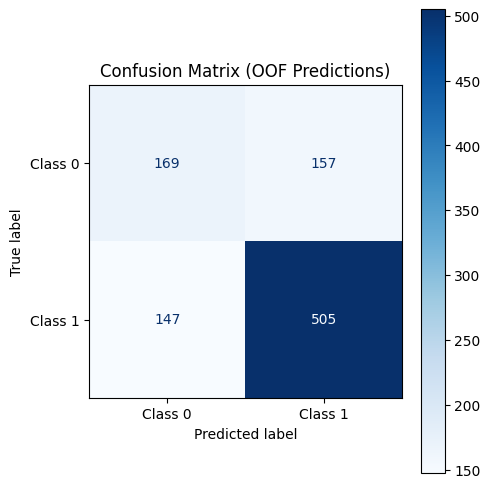

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    oof_df["y_true"],
    oof_df["y_pred"],
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Confusion Matrix (OOF Predictions)")

plt.tight_layout()
plt.show()

In [45]:
# =========================================================
# STEP 6 — Final model: majority vote per-parameter,
# refit on 100% of training data
# Model 01: TF-IDF + Logistic Regression
# =========================================================
from collections import Counter

param_names = params_history[0].keys()
final_params = {}

print("Voto di maggioranza per parametro:")
for name in param_names:
    values = [p[name] for p in params_history]
    # i valori tipo ngram_range sono tuple, quindi hashable e contabili direttamente
    most_common_value, count = Counter(values).most_common(1)[0]
    final_params[name] = most_common_value
    print(f"  {name:35s} -> {most_common_value}  ({count}/{N_FOLDS} fold)")

print("\nParametri finali scelti:")
print(final_params)

final_pipeline = pipeline.set_params(**final_params)
final_pipeline.fit(df["text_bert"], df["binary_label"])

print("\nModello finale TF-IDF fittato su tutto il training set.")

Voto di maggioranza per parametro:
  clf__C                              -> 1  (4/5 fold)
  clf__penalty                        -> l2  (5/5 fold)
  clf__solver                         -> liblinear  (5/5 fold)
  features__tfidf__max_df             -> 0.95  (3/5 fold)
  features__tfidf__max_features       -> 3000  (3/5 fold)
  features__tfidf__min_df             -> 3  (5/5 fold)
  features__tfidf__ngram_range        -> (1, 2)  (3/5 fold)
  features__tfidf__sublinear_tf       -> True  (4/5 fold)

Parametri finali scelti:
{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'features__tfidf__max_df': 0.95, 'features__tfidf__max_features': 3000, 'features__tfidf__min_df': 3, 'features__tfidf__ngram_range': (1, 2), 'features__tfidf__sublinear_tf': True}

Modello finale TF-IDF fittato su tutto il training set.


In [46]:
# =========================================================
# STEP 7 — Load external holdout test set
# Model 01: TF-IDF + Logistic Regression
# =========================================================
HOLDOUT_PATH = "../Dati/Processed/test_holdout_processed.csv"   # output di 02c_preprocessing_test_holdout.py

holdout = pd.read_csv(HOLDOUT_PATH)
print(f"[holdout] {holdout.shape[0]} righe, {holdout['topic_id'].nunique()} topic")

# controllo overlap topic tra training e holdout
overlap = set(df["topic_id"]) & set(holdout["topic_id"])
print(f"Topic in comune training/holdout: {len(overlap)}")
if overlap:
    print("ATTENZIONE — rimuovo i topic in overlap dall'holdout:")
    print(overlap)
    holdout = holdout[~holdout["topic_id"].isin(overlap)].copy()
    print(f"Holdout dopo rimozione overlap: {holdout.shape[0]} righe")

[holdout] 69 righe, 23 topic
Topic in comune training/holdout: 0


HOLDOUT RESULTS — TF-IDF + Logistic Regression
Macro F1 : 0.6612
Accuracy : 0.6957

              precision    recall  f1-score   support

           0      0.542     0.565     0.553        23
           1      0.778     0.761     0.769        46

    accuracy                          0.696        69
   macro avg      0.660     0.663     0.661        69
weighted avg      0.699     0.696     0.697        69



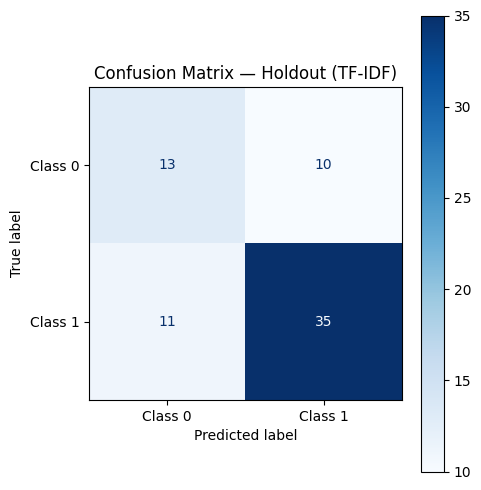

In [47]:
# =========================================================
# STEP 8 — Evaluate final TF-IDF model on holdout
# Model 01: TF-IDF + Logistic Regression
# =========================================================
X_holdout = holdout["text_bert"]
y_holdout = holdout["binary_label"]

y_pred_holdout = final_pipeline.predict(X_holdout)
y_prob_holdout = final_pipeline.predict_proba(X_holdout)[:, 1]

holdout_f1 = f1_score(y_holdout, y_pred_holdout, average="macro")
holdout_acc = accuracy_score(y_holdout, y_pred_holdout)

print("HOLDOUT RESULTS — TF-IDF + Logistic Regression")
print(f"Macro F1 : {holdout_f1:.4f}")
print(f"Accuracy : {holdout_acc:.4f}\n")
print(classification_report(y_holdout, y_pred_holdout, digits=3))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_holdout, y_pred_holdout,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues", values_format="d", ax=ax
)
ax.set_title("Confusion Matrix — Holdout (TF-IDF)")
plt.tight_layout()
plt.show()

In [48]:
import numpy as np

rng = np.random.default_rng(SEED)
n_boot = 2000
boot_f1 = []

y_true_arr = y_holdout.values
y_pred_arr = y_pred_holdout

for _ in range(n_boot):
    idx = rng.integers(0, len(y_true_arr), len(y_true_arr))
    boot_f1.append(f1_score(y_true_arr[idx], y_pred_arr[idx], average="macro"))

ci_low, ci_high = np.percentile(boot_f1, [2.5, 97.5])
print(f"Macro F1 holdout: {holdout_f1:.4f}")
print(f"95% CI (bootstrap): [{ci_low:.4f}, {ci_high:.4f}]")

Macro F1 holdout: 0.6612
95% CI (bootstrap): [0.5329, 0.7703]
